In [1]:
# --- Cell 1: Imports ---
from openeye import oechem, oeomega, oeshape
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import matplotlib.pyplot as plt
import time

# Load OpenEye license
oechem.OEAddLicenseData(open(r"C:\Users\Admin\.OpenEye\oe_license.txt").read())

In [2]:
# --- Cell 2: Load and Clean Data ---
# Load the CSV
df = pd.read_csv("antiviral_potency_2025_unblinded.csv")
print(f"Total molecules in dataset: {len(df)}")
print(f"Columns: {list(df.columns)}")

# Define target columns
SARS_COL = "pIC50 (SARS-CoV-2 Mpro)"
MERS_COL = "pIC50 (MERS-CoV Mpro)"

# Check missing values
print(f"\nMissing values:")
print(f"  SARS-CoV-2 pIC50: {df[SARS_COL].isna().sum()}")
print(f"  MERS-CoV pIC50:   {df[MERS_COL].isna().sum()}")

# Strategy: use only molecules that have BOTH pIC50 values
# This way SARS and MERS models share the same ROCS matrix
working_df = df[["CXSMILES", "Molecule Name", "Set", SARS_COL, MERS_COL]].dropna()
print(f"\nMolecules with both SARS and MERS pIC50: {len(working_df)}")
print(f"  Train: {(working_df['Set'] == 'Train').sum()}")
print(f"  Test:  {(working_df['Set'] == 'Test').sum()}")

# Quick look at target distributions
print(f"\nSARS pIC50 stats:")
print(working_df[SARS_COL].describe())
print(f"\nMERS pIC50 stats:")
print(working_df[MERS_COL].describe())

Total molecules in dataset: 1328
Columns: ['CXSMILES', 'Molecule Name', 'Set', 'pIC50 (MERS-CoV Mpro)', 'pIC50 (SARS-CoV-2 Mpro)']

Missing values:
  SARS-CoV-2 pIC50: 223
  MERS-CoV pIC50:   130

Molecules with both SARS and MERS pIC50: 975
  Train: 712
  Test:  263

SARS pIC50 stats:
count    975.000000
mean       5.671169
std        1.168357
min        4.000000
25%        4.720000
50%        5.380000
75%        6.560000
max        8.730000
Name: pIC50 (SARS-CoV-2 Mpro), dtype: float64

MERS pIC50 stats:
count    975.000000
mean       4.962697
std        0.862631
min        1.000000
25%        4.310000
50%        4.780000
75%        5.510000
max        9.000000
Name: pIC50 (MERS-CoV Mpro), dtype: float64


In [3]:
# --- Cell 3: Generate 3D Conformers with OMEGA ---
print("\n--- Generating 3D Conformers ---")

omega_opts = oeomega.OEOmegaOptions(oeomega.OEOmegaSampling_ROCS)
omega = oeomega.OEOmega(omega_opts)

mol_list = []
sars_values = []
mers_values = []
set_labels = []
mol_names = []
failed_count = 0

for idx, row in working_df.iterrows():
    smiles = row["CXSMILES"]
    mol = oechem.OEMol()
    oechem.OESmilesToMol(mol, smiles)

    ret_code = omega.Build(mol)
    if ret_code == oeomega.OEOmegaReturnCode_Success:
        mol_list.append(oechem.OEMol(mol))
        sars_values.append(row[SARS_COL])
        mers_values.append(row[MERS_COL])
        set_labels.append(row["Set"])
        mol_names.append(row["Molecule Name"])
    else:
        failed_count += 1

N = len(mol_list)
print(f"Successfully generated 3D conformers: {N}")
print(f"Failed: {failed_count}")

# Convert to numpy arrays
sars_values = np.array(sars_values)
mers_values = np.array(mers_values)
set_labels = np.array(set_labels)


--- Generating 3D Conformers ---
Successfully generated 3D conformers: 963
Failed: 12


In [4]:
# --- Cell 5: Load Saved Matrices ---
# (If you restart the kernel, run Cell 1 first for imports, then this cell)
shape_matrix = np.load("shape_matrix_both.npy")
color_matrix = np.load("color_matrix_both.npy")
sars_values = np.load("sars_values.npy")
mers_values = np.load("mers_values.npy")
set_labels = np.load("set_labels.npy", allow_pickle=True)
N = len(sars_values)
print(f"Loaded data for {N} molecules")

Loaded data for 963 molecules


In [5]:
# --- Cell 6: Build Feature Matrix and Train/Test Split ---
# Concatenate shape and color matrices: each molecule gets 2*N features
features = np.concatenate([shape_matrix, color_matrix], axis=1)
print(f"Feature matrix shape: {features.shape}")
print(f"  {N} shape features + {N} color features = {2*N} total features per molecule")

# Use the dataset's built-in train/test split
train_mask = set_labels == "Train"
test_mask = set_labels == "Test"

train_X = features[train_mask]
test_X = features[test_mask]

# SARS targets
train_y_sars = sars_values[train_mask]
test_y_sars = sars_values[test_mask]

# MERS targets
train_y_mers = mers_values[train_mask]
test_y_mers = mers_values[test_mask]

print(f"\nTrain set: {train_X.shape[0]} molecules")
print(f"Test set:  {test_X.shape[0]} molecules")

Feature matrix shape: (963, 1926)
  963 shape features + 963 color features = 1926 total features per molecule

Train set: 701 molecules
Test set:  262 molecules


In [6]:
# --- Cell 7: Define Evaluation Function ---
def evaluate_model(name, y_true, y_pred):
    """Print evaluation metrics for a model."""
    rho, _ = spearmanr(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Spearman rho:  {rho:.4f}")
    print(f"  MAE:           {mae:.4f}")
    print(f"  RMSE:          {rmse:.4f}")
    print(f"{'='*50}")
    return rho, mae, rmse

def plot_predicted_vs_actual(y_true, y_pred, title):
    """Scatter plot of predicted vs actual values."""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, s=15, alpha=0.6)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.3, label="Perfect prediction")
    ax.set_xlabel("Experimental pIC50")
    ax.set_ylabel("Predicted pIC50")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

  MODEL A: Predicting SARS-CoV-2 Mpro pIC50

  SARS - Random Forest
  Spearman rho:  0.8151
  MAE:           0.6780
  RMSE:          0.8532


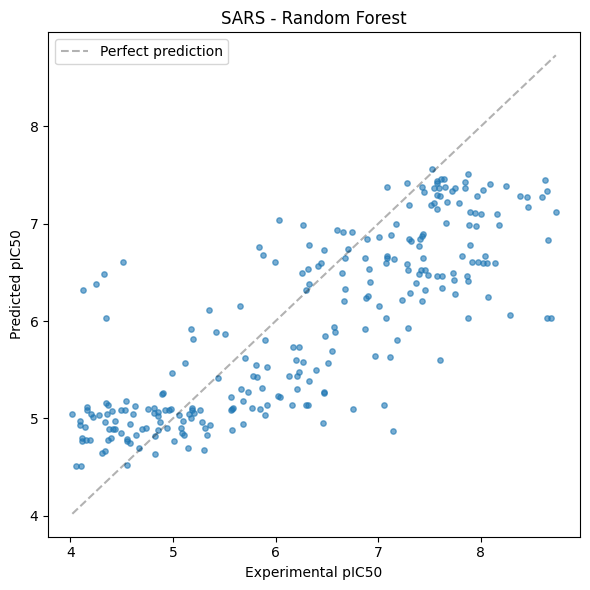


  SARS - XGBoost
  Spearman rho:  0.8262
  MAE:           0.6257
  RMSE:          0.8062


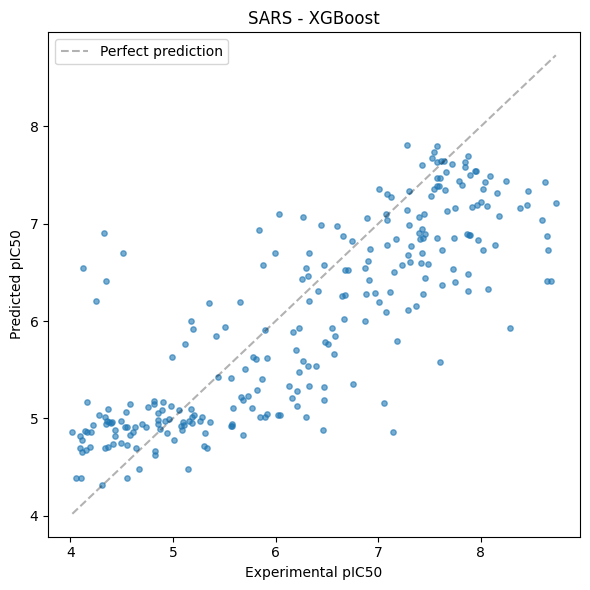

In [7]:
# --- Cell 8: Model A - Predict SARS-CoV-2 pIC50 ---
print("=" * 60)
print("  MODEL A: Predicting SARS-CoV-2 Mpro pIC50")
print("=" * 60)

# Random Forest
rf_sars = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_split=2, min_samples_leaf=1, random_state=42, n_jobs=-1)
rf_sars.fit(train_X, train_y_sars)
rf_sars_pred = rf_sars.predict(test_X)
rf_sars_metrics = evaluate_model("SARS - Random Forest", test_y_sars, rf_sars_pred)
plot_predicted_vs_actual(test_y_sars, rf_sars_pred, "SARS - Random Forest")

# XGBoost
xgb_sars = xgb.XGBRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.7, colsample_bytree=0.7
    , random_state=42, n_jobs=-1
)
xgb_sars.fit(train_X, train_y_sars)
xgb_sars_pred = xgb_sars.predict(test_X)
xgb_sars_metrics = evaluate_model("SARS - XGBoost", test_y_sars, xgb_sars_pred)
plot_predicted_vs_actual(test_y_sars, xgb_sars_pred, "SARS - XGBoost")

  MODEL B: Predicting MERS-CoV Mpro pIC50

  MERS - Random Forest
  Spearman rho:  0.7870
  MAE:           0.5095
  RMSE:          0.6492


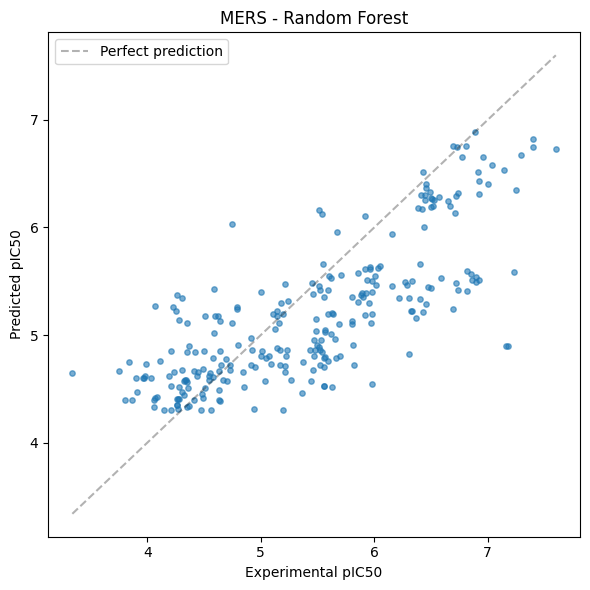


  MERS - XGBoost
  Spearman rho:  0.7757
  MAE:           0.5041
  RMSE:          0.6391


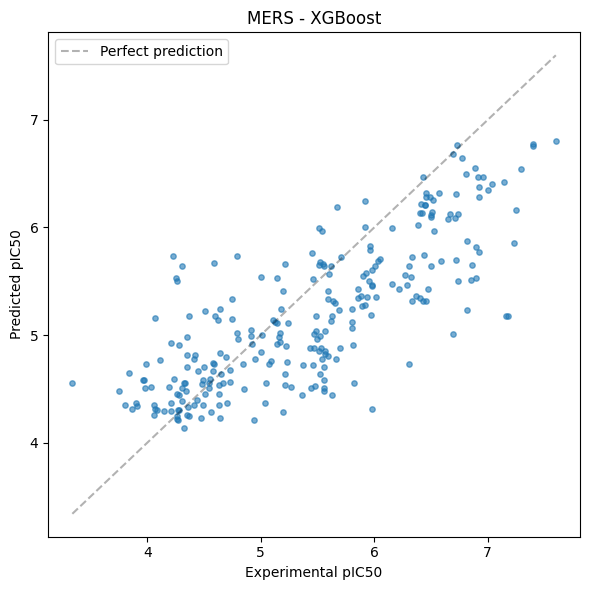

In [8]:
# --- Cell 9: Model B - Predict MERS-CoV pIC50 ---
print("=" * 60)
print("  MODEL B: Predicting MERS-CoV Mpro pIC50")
print("=" * 60)

# Random Forest
rf_mers = RandomForestRegressor(n_estimators=500, max_depth=12, min_samples_split=2, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_mers.fit(train_X, train_y_mers)
rf_mers_pred = rf_mers.predict(test_X)
rf_mers_metrics = evaluate_model("MERS - Random Forest", test_y_mers, rf_mers_pred)
plot_predicted_vs_actual(test_y_mers, rf_mers_pred, "MERS - Random Forest")

# XGBoost
xgb_mers = xgb.XGBRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.7,
      colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_mers.fit(train_X, train_y_mers)
xgb_mers_pred = xgb_mers.predict(test_X)
xgb_mers_metrics = evaluate_model("MERS - XGBoost", test_y_mers, xgb_mers_pred)
plot_predicted_vs_actual(test_y_mers, xgb_mers_pred, "MERS - XGBoost")

results = {
    "SARS - RF": rf_sars,
    "SARS - XGBoost": xgb_sars,
    "MERS - RF": rf_mers,
    "MERS - XGBoost": xgb_mers,
}

In [9]:
# --- Cell 10: Summary Comparison ---
print("\n" + "=" * 70)
print("  SUMMARY: All Models Comparison")
print("=" * 70)
print(f"{'Model':<25} {'Spearman':>10} {'MAE':>10} {'RMSE':>10}")
print("-" * 55)
print(f"{'SARS - Random Forest':<25} {rf_sars_metrics[0]:>10.4f} {rf_sars_metrics[1]:>10.4f} {rf_sars_metrics[2]:>10.4f}")
print(f"{'SARS - XGBoost':<25} {xgb_sars_metrics[0]:>10.4f} {xgb_sars_metrics[1]:>10.4f} {xgb_sars_metrics[2]:>10.4f}")
print(f"{'MERS - Random Forest':<25} {rf_mers_metrics[0]:>10.4f} {rf_mers_metrics[1]:>10.4f} {rf_mers_metrics[2]:>10.4f}")
print(f"{'MERS - XGBoost':<25} {xgb_mers_metrics[0]:>10.4f} {xgb_mers_metrics[1]:>10.4f} {xgb_mers_metrics[2]:>10.4f}")
print("=" * 70)


  SUMMARY: All Models Comparison
Model                       Spearman        MAE       RMSE
-------------------------------------------------------
SARS - Random Forest          0.8151     0.6780     0.8532
SARS - XGBoost                0.8262     0.6257     0.8062
MERS - Random Forest          0.7870     0.5095     0.6492
MERS - XGBoost                0.7757     0.5041     0.6391


In [10]:
# --- Cell 11: Overfitting Check ---
print("OVERFITTING CHECK: Train vs Test")
print("=" * 65)
print(f"{'Model':<25} {'Train Spearman':>15} {'Test Spearman':>15} {'Gap':>10}")
print("-" * 65)

for name, model, train_y, test_y, test_pred in [
    ("SARS - RF", rf_sars, train_y_sars, test_y_sars, rf_sars_pred),
    ("SARS - XGBoost", xgb_sars, train_y_sars, test_y_sars, xgb_sars_pred),
    ("MERS - RF", rf_mers, train_y_mers, test_y_mers, rf_mers_pred),
    ("MERS - XGBoost", xgb_mers, train_y_mers, test_y_mers, xgb_mers_pred),
]:
    train_pred = model.predict(train_X)
    train_rho, _ = spearmanr(train_y, train_pred)
    test_rho, _ = spearmanr(test_y, test_pred)
    gap = train_rho - test_rho
    print(f"{name:<25} {train_rho:>15.4f} {test_rho:>15.4f} {gap:>10.4f}")

print("=" * 65)
print("Gap < 0.10 = good | Gap 0.10-0.15 = okay | Gap > 0.15 = overfitting")

OVERFITTING CHECK: Train vs Test
Model                      Train Spearman   Test Spearman        Gap
-----------------------------------------------------------------
SARS - RF                          0.9560          0.8151     0.1409
SARS - XGBoost                     0.9445          0.8262     0.1183
MERS - RF                          0.9190          0.7870     0.1320
MERS - XGBoost                     0.9470          0.7757     0.1713
Gap < 0.10 = good | Gap 0.10-0.15 = okay | Gap > 0.15 = overfitting


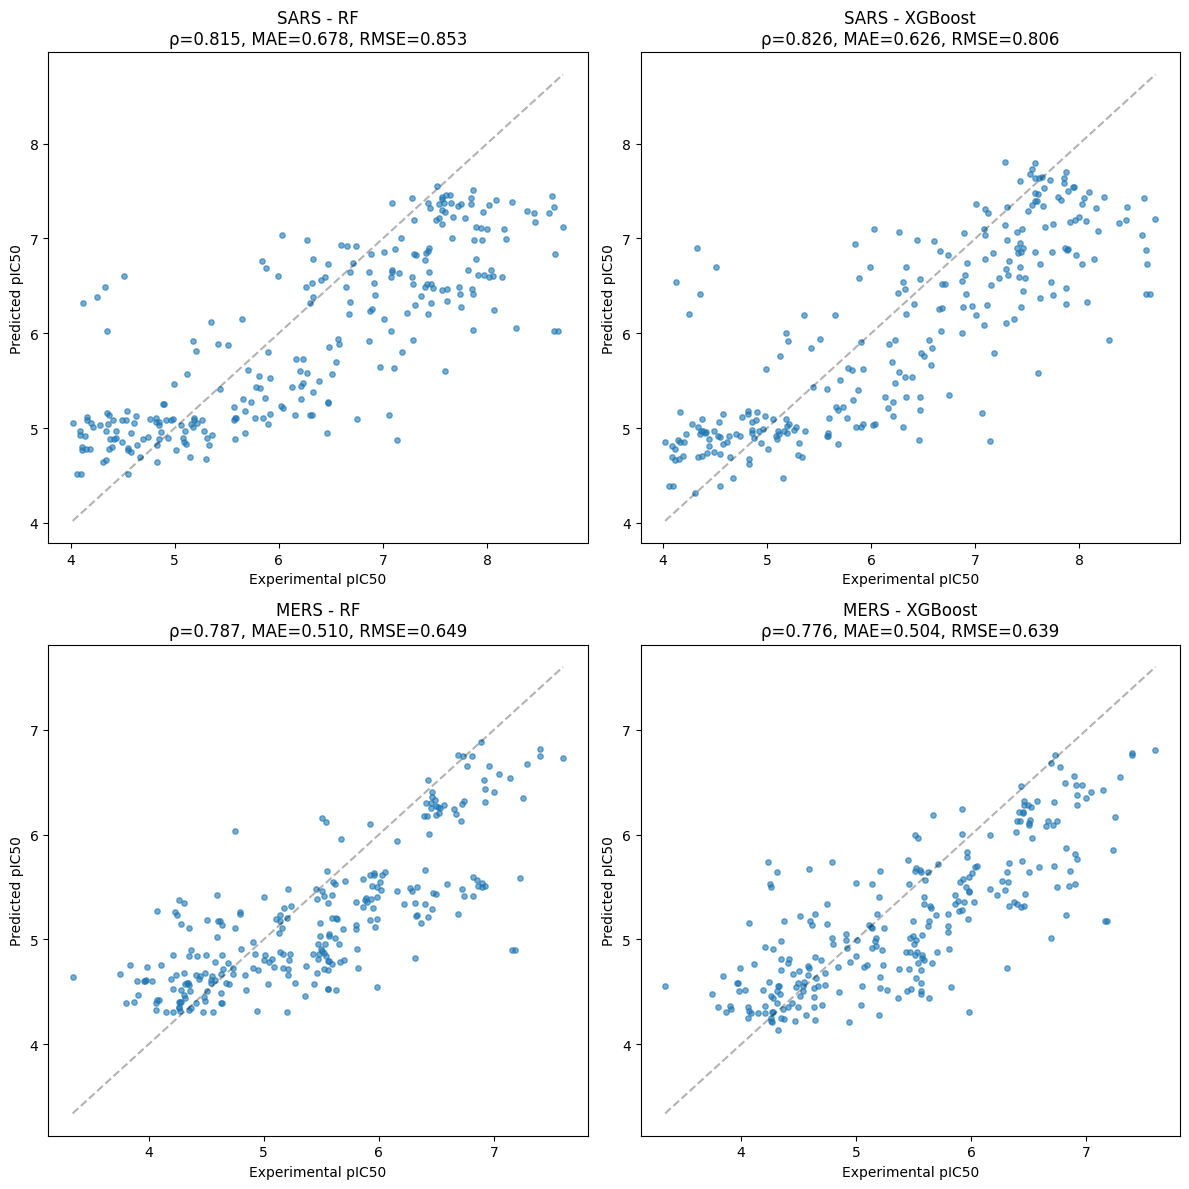

In [11]:
# --- Cell 13: Scatter Plots for Tuned Models ---
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for idx, (name, model) in enumerate(results.items()):
    ax = axes[idx // 2][idx % 2]
    target_test = test_y_sars if "SARS" in name else test_y_mers
    test_pred = model.predict(test_X)

    # Get metrics for title
    rho, _ = spearmanr(target_test, test_pred)
    mae = mean_absolute_error(target_test, test_pred)
    rmse = np.sqrt(mean_squared_error(target_test, test_pred))

    ax.scatter(target_test, test_pred, s=15, alpha=0.6)
    min_val = min(target_test.min(), test_pred.min())
    max_val = max(target_test.max(), test_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.3)
    ax.set_xlabel("Experimental pIC50")
    ax.set_ylabel("Predicted pIC50")
    ax.set_title(f"{name}\nρ={rho:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}")

plt.tight_layout()
plt.show()

In [12]:
# --- Cell 14: Load and Predict on Unseen Data ---

# Step 1: Load unseen molecules from .oez file
print("Loading unseen molecules...")
unseen_ifs = oechem.oemolistream("Cresset_OE_Mpro_76cmpds.oez")
unseen_mols = []
unseen_names = []

for mol in unseen_ifs.GetOEMols():
    unseen_mols.append(oechem.OEMol(mol))
    unseen_names.append(mol.GetTitle())

unseen_ifs.close()
print(f"Loaded {len(unseen_mols)} unseen molecules")

# Step 2: Compute ROCS features for unseen molecules vs training molecules
# Each unseen molecule needs shape and color scores against all 963 training molecules
print(f"\nComputing ROCS features for {len(unseen_mols)} unseen molecules vs {N} training molecules...")
print("This should take a few minutes...\n")

unseen_shape = np.zeros((len(unseen_mols), N))
unseen_color = np.zeros((len(unseen_mols), N))

prep = oeshape.OEOverlapPrep()
start_time = time.time()

for i, query in enumerate(unseen_mols):
    prep.Prep(query)
    overlay = oeshape.OEOverlay()
    overlay.SetupRef(query)

    for j, fitmol in enumerate(mol_list):
        prep.Prep(fitmol)
        score = oeshape.OEBestOverlayScore()
        overlay.BestOverlay(score, fitmol)
        unseen_shape[i][j] = score.GetShapeTanimoto()
        unseen_color[i][j] = score.GetColorTanimoto()

    if (i + 1) % 10 == 0 or (i + 1) == len(unseen_mols):
        elapsed = time.time() - start_time
        print(f"[{i+1}/{len(unseen_mols)}] Elapsed: {elapsed/60:.1f} min")

print(f"\nDone! Total time: {(time.time() - start_time)/60:.1f} minutes")

# Step 3: Build feature matrix for unseen data
unseen_features = np.concatenate([unseen_shape, unseen_color], axis=1)
print(f"Unseen feature matrix shape: {unseen_features.shape}")

# Step 4: Predict using tuned models
print("\n" + "=" * 60)
print("  PREDICTIONS ON UNSEEN DATA")
print("=" * 60)

for name, model in results.items():
    preds = model.predict(unseen_features)
    print(f"\n{name}:")
    print(f"  Predicted pIC50 range: {preds.min():.3f} to {preds.max():.3f}")
    print(f"  Predicted pIC50 mean:  {preds.mean():.3f}")
    print(f"  Predicted pIC50 std:   {preds.std():.3f}")

# Step 5: Save predictions to CSV
print("\n--- Saving predictions to CSV ---")
pred_df = pd.DataFrame({"Molecule Name": unseen_names})

for name, model in results.items():
    col_name = name.replace(" - ", "_").replace(" ", "_")
    pred_df[col_name] = model.predict(unseen_features)

pred_df.to_csv("unseen_predictions.csv", index=False)
print("Saved to unseen_predictions.csv")
print(pred_df.head(10))

Loading unseen molecules...
Loaded 76 unseen molecules

Computing ROCS features for 76 unseen molecules vs 963 training molecules...
This should take a few minutes...

[10/76] Elapsed: 3.5 min
[20/76] Elapsed: 6.9 min
[30/76] Elapsed: 10.2 min
[40/76] Elapsed: 13.7 min
[50/76] Elapsed: 16.3 min
[60/76] Elapsed: 19.7 min
[70/76] Elapsed: 22.7 min
[76/76] Elapsed: 24.3 min

Done! Total time: 24.3 minutes
Unseen feature matrix shape: (76, 1926)

  PREDICTIONS ON UNSEEN DATA

SARS - RF:
  Predicted pIC50 range: 4.675 to 6.704
  Predicted pIC50 mean:  5.882
  Predicted pIC50 std:   0.573

SARS - XGBoost:
  Predicted pIC50 range: 4.434 to 6.801
  Predicted pIC50 mean:  5.940
  Predicted pIC50 std:   0.654

MERS - RF:
  Predicted pIC50 range: 4.308 to 5.115
  Predicted pIC50 mean:  4.814
  Predicted pIC50 std:   0.205

MERS - XGBoost:
  Predicted pIC50 range: 4.168 to 5.334
  Predicted pIC50 mean:  4.887
  Predicted pIC50 std:   0.301

--- Saving predictions to CSV ---
Saved to unseen_predict